In [1]:
# Автоматическая перезагрузка модулей при изменении
# Позволяет обновлять код в helper.py, plots.py, nlp.py без перезапуска ядра
%load_ext autoreload
%autoreload 2

In [26]:
# Импорт библиотек для классического ML и нейронных сетей
import pandas as pd
import numpy as np
import random

# Импорт sklearn для классических алгоритмов
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from lightgbm import LGBMClassifier

# Импорт TensorFlow/Keras для нейронных сетей
import tensorflow as tf
from tensorflow.keras.utils import set_random_seed, to_categorical
from tensorflow.keras.regularizers import l2 as l2_reg
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import Constant
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, SimpleRNN, Dense, Dropout, Conv1D, GlobalMaxPooling1D
from tensorflow.config.experimental import list_physical_devices
from tensorflow.keras.layers import LSTM

# Пользовательские модули
from helper import *        # вспомогательные функции
from plots import *         # функции визуализации
from nlp import *          # функции обработки естественного языка
from transformers import * # функции для работы с трансформерами
from keras_helper import * # функции для работы с Keras

In [3]:
# Проверка GPU
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU доступен: {len(gpus)} устройств")
else:
    print("GPU недоступен, используется CPU")

GPU недоступен, используется CPU


In [4]:
# Фиксация состояния генератора псевдослучайных чисел для воспроизводимости
# Критически важно для машинного обучения - результаты должны быть воспроизводимы
SEED = 42 # можно указать любое число
np.random.seed(SEED)  # для numpy операций
random.seed(SEED)     # для стандартного модуля random
set_random_seed(SEED) # для TensorFlow/Keras

In [5]:
# Загружаем предобработанные данные
df = pd.read_csv('Data/movie.csv')

## 1. Препроцессинг и бейслайн

In [6]:
# Создаем копию данных для предобработки
df_preprocessed = df.copy()
# удалим дубликаты
df_preprocessed = df_preprocessed.drop_duplicates()

# Токенизируем тексты с помощью tiktoken (токенизатор GPT)
# Это необходимо для дальнейшей векторизации текстов
df_preprocessed['text'] = df_preprocessed['text'].apply(tokenize_tiktoken)

# Удаляем стоп-слова
df_preprocessed[['text']] = df_preprocessed[['text']].map(lambda tokens: filter_tokens(
    tokens, 
    remove_stopwords=True, 
    remove_punct_tokens=True,
    lowercase_for_counting=True
))

In [7]:
# Разделяем данные на признаки (X) и целевую переменную (y)
X, y = divide_data(df_preprocessed, 'label')

In [8]:
# Создаем baseline модель LGBM для сравнения с нейронными сетями
lgbm_classifier = LGBMClassifier(random_state=SEED, verbose=-1)

In [9]:
# Настраиваем кросс-валидацию с 3 фолдами (меньше для ускорения обучения нейронных сетей)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

In [10]:
# Создаем пайплайн для векторизации текстов (для baseline модели)
count_vectorizer_preprocessor = Pipeline([
    ('vectorizer', ColumnTransformer(
        [
            ('description_vectorizer', CountVectorizer(analyzer=lambda x: x, min_df=50, dtype=np.float32), 'text'),
        ],
        remainder='passthrough', 
        verbose_feature_names_out=True
    )),
])

c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.

<Figure size 1500x600 with 0 Axes>

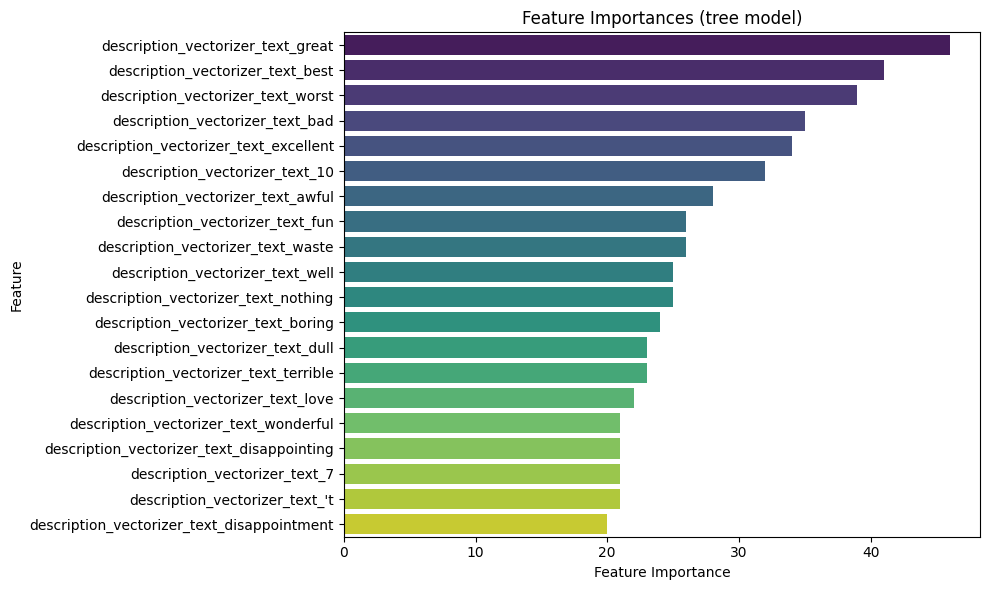

In [11]:

baseline_metrics = train_evaluate_model_cv(
    model=lgbm_classifier,
    model_name='LGBMClassifier',
    X=X,
    y=y,
    preprocessor=count_vectorizer_preprocessor,
    cv=cv,
    seed=SEED
)

In [12]:
# Выводим метрики baseline модели
baseline_metrics

ClassificationMetrics(name='LGBMClassifier', training_time=10.3233962059021, estimators=None, roc_auc=0.9377614087634306, f1_score=0.8583830818306512, precision=0.8587032412360797, recall=0.8583875418142228, accuracy=0.8584195554212924, confusion_matrix=None, classification_report=None, roc_curve=None)

## Препроцессинг перед использованием нейросетей

In [13]:
# Параметры для нейронных сетей
MAX_NUM_WORDS = 100        # максимальное количество уникальных слов в словаре
MAX_SEQUENCE_LENGTH = 600  # максимальная длина последовательности токенов

In [14]:
# Демонстрация процесса предобработки для нейронных сетей
X_lol = X.copy()

# Отбираем топ-100 наиболее важных токенов для создания словаря
feature_selector = NgramFeatureSelector(top_k=MAX_NUM_WORDS)
X_lol['text'] = feature_selector.fit_transform(X_lol['text'])

In [15]:
# Преобразуем токены в последовательности чисел для нейронных сетей
vect = SequenceVectorizer(min_frequency=50, max_sequence_length=MAX_SEQUENCE_LENGTH, pad_left=False)
X_lol = vect.fit_transform(X_lol['text'])

In [16]:
# Результат: каждая строка - это последовательность индексов токенов
# Длина каждой последовательности <= MAX_SEQUENCE_LENGTH (600)
X_lol

array([[43, 69,  7, ...,  0,  0,  0],
       [ 4,  4, 12, ...,  0,  0,  0],
       [20, 46, 11, ...,  0,  0,  0],
       ...,
       [ 4, 43, 95, ...,  0,  0,  0],
       [23,  9,  4, ...,  0,  0,  0],
       [12,  5,  9, ...,  0,  0,  0]], dtype=int32)

In [17]:
# Создаем пайплайн предобработки для нейронных сетей
RNN_preprocessor = Pipeline([
    ('token_selector', NgramFeatureSelector(top_k=100)),  # отбираем топ-100 важных токенов
    ('seq_vec', SequenceVectorizer(                       # преобразуем в последовательности
        min_frequency=50,                                 # минимальная частота токена
        max_sequence_length=MAX_SEQUENCE_LENGTH,          # максимальная длина последовательности
        pad_left=False                                    # дополнение справа (стандарт для RNN)
    ))
])

## 2. RNN (Рекуррентная нейронная сеть)

Fold 1


c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - AUC: 0.8186 - loss: 0.5242
Epoch 2/50
  3/104 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - AUC: 0.8608 - loss: 0.4696

c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\callbacks\early_stopping.py:100: UserWarning: Early stopping conditioned on metric `auc` which is not available. Available metrics are: AUC,loss
  current = self.get_monitor_value(logs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - AUC: 0.8462 - loss: 0.4895
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - AUC: 0.8616 - loss: 0.4674
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - AUC: 0.8635 - loss: 0.4659
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - AUC: 0.8110 - loss: 0.5378
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - AUC: 0.8278 - loss: 0.5214
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - AUC: 0.8649 - loss: 0.4663
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - AUC: 0.8705 - loss: 0.4571
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - AUC: 0.8680 - loss: 0.4618
Epoch 10/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - AUC: 0.8703 - loss: 0.4578
Epoch 11/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - AUC: 0.8737 - loss: 0.4522
Epoch 12/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - AUC: 0.8700 - loss: 0.4575
Epoch 13/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - AUC: 0.8743 - loss: 0.4518
Epoch 14/50
104/104 ━━━

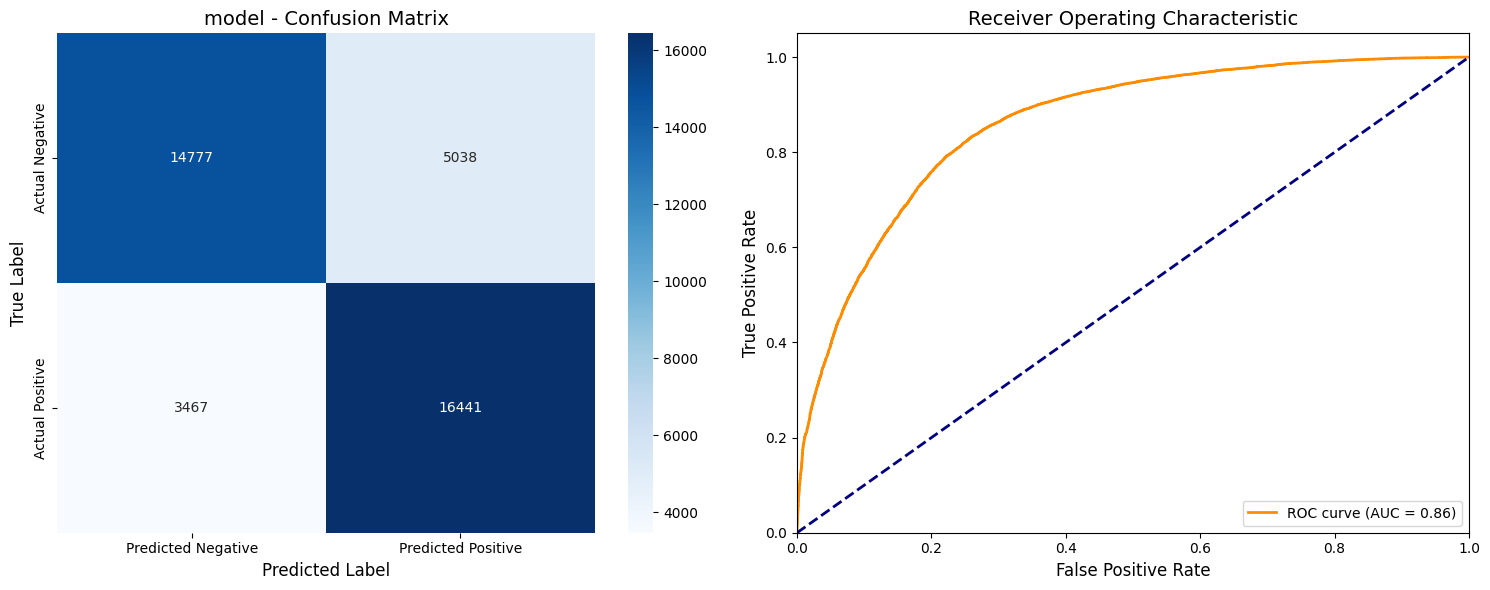

In [18]:
# Гиперпараметры для RNN модели
LEARNING_RATE = 0.01        # скорость обучения
BATCH_SIZE = 256           # размер батча
RNN_UNITS = 8              # количество нейронов в RNN слое
EMBEDDING_DIM = 10         # размерность эмбеддингов слов

DROPOUT_RATE = 0.5         # dropout для предотвращения переобучения
RECCURENT_DROPOUT_RATE = 0 # dropout для рекуррентных соединений
DROPOUT_LAYER_RATE = 0.0   # dropout для дополнительных слоев

REGULARIZATION_STRENGTH = 0.0001  # сила L2 регуляризации

# Функция создания RNN модели
def build_rnn_model():
    model = Sequential([
        # Слой эмбеддингов: преобразует индексы токенов в плотные векторы
        Embedding(input_dim=MAX_NUM_WORDS + 1, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH,
                    embeddings_regularizer=l2_reg(REGULARIZATION_STRENGTH)),
        
        # Двунаправленная RNN: анализирует последовательность в обе стороны
        Bidirectional(SimpleRNN(RNN_UNITS, dropout=DROPOUT_RATE, recurrent_dropout=RECCURENT_DROPOUT_RATE, return_sequences=False)),
        
        # Выходной слой для бинарной классификации
        Dense(1, activation="sigmoid")
    ])
    
    # Компилируем модель с оптимизатором Adam
    optimizer = Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["AUC"])
    return model

# Параметры обучения
fit_params = dict(
    epochs=50,  # максимальное количество эпох
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='auc', mode='max', patience=5, restore_best_weights=True)],  # ранняя остановка
    verbose=1
)

# Обучаем RNN модель с кросс-валидацией
rnn_metrics = cross_validate_model(
    model_builder=build_rnn_model,
    X=X['text'],
    y=y,
    preprocessor=RNN_preprocessor,
    cv=cv,
    fit_params=fit_params
)

In [19]:
# Результаты обучения RNN модели
rnn_metrics.name = 'RNN'
rnn_metrics

ClassificationMetrics(name='RNN', training_time=716.4891141999979, estimators=[{'preprocessor': Pipeline(steps=[('token_selector', NgramFeatureSelector()),
                ('seq_vec',
                 SequenceVectorizer(max_sequence_length=600, min_frequency=50,
                                    pad_left=False))]), 'model': <Sequential name=sequential, built=True>}, {'preprocessor': Pipeline(steps=[('token_selector', NgramFeatureSelector()),
                ('seq_vec',
                 SequenceVectorizer(max_sequence_length=600, min_frequency=50,
                                    pad_left=False))]), 'model': <Sequential name=sequential_1, built=True>}, {'preprocessor': Pipeline(steps=[('token_selector', NgramFeatureSelector()),
                ('seq_vec',
                 SequenceVectorizer(max_sequence_length=600, min_frequency=50,
                                    pad_left=False))]), 'model': <Sequential name=sequential_2, built=True>}], roc_auc=0.856078308439868, f1_score=0.78

## 3. CNN (Сверточная нейронная сеть)

Fold 1


c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.8615 - loss: 0.5067
Epoch 2/50
 33/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8718 - loss: 0.4846

c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\callbacks\early_stopping.py:100: UserWarning: Early stopping conditioned on metric `auc` which is not available. Available metrics are: AUC,loss
  current = self.get_monitor_value(logs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8789 - loss: 0.4721
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8818 - loss: 0.4652
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8833 - loss: 0.4615
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8852 - loss: 0.4576
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8862 - loss: 0.4555
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8865 - loss: 0.4537
Epoch 8/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8873 - loss: 0.4524
Epoch 9/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8881 - loss: 0.4508
Epoch 10/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8884 - loss: 0.4491
Epoch 11/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8885 - loss: 0.4482
Epoch 12/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8898 - loss: 0.4459
Epoch 13/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8901 - loss: 0.4450
Epoch 14/50
207/207 ━━━━━━━━━━━━━━━

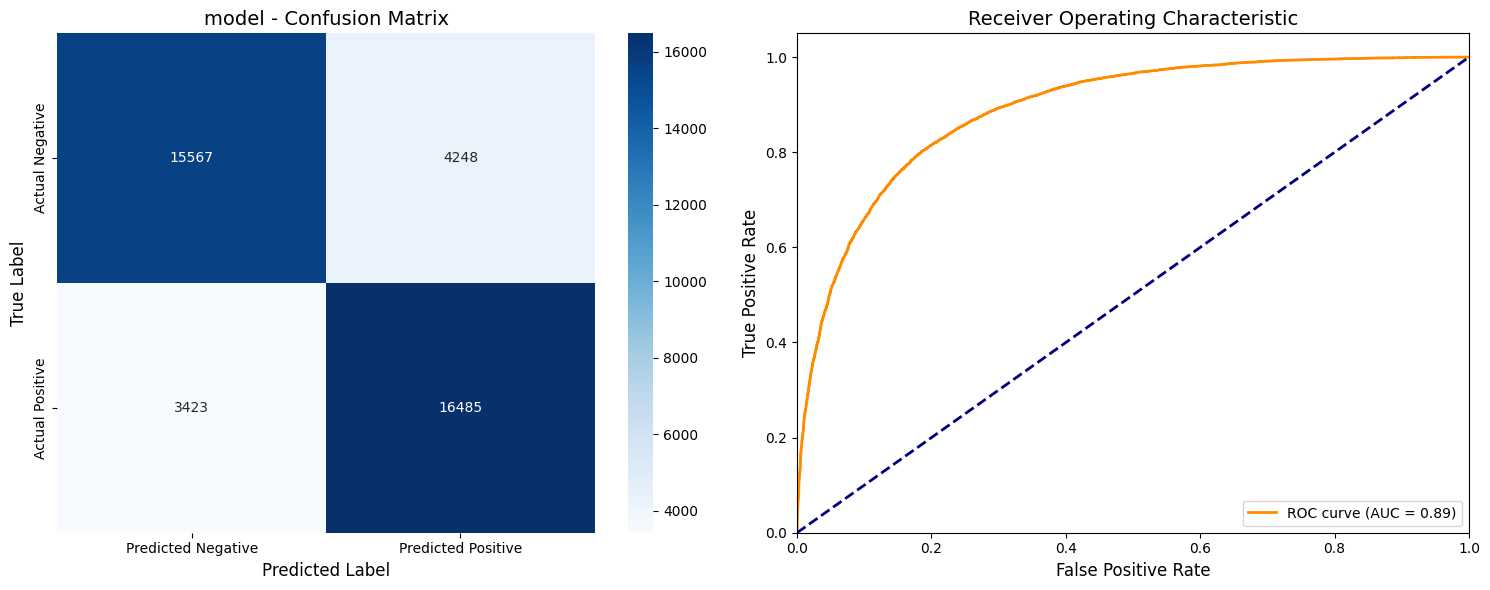

In [20]:
# Гиперпараметры для CNN модели
LEARNING_RATE = 0.01
BATCH_SIZE = 128          # меньший батч для CNN
FILTERS = 8               # количество сверточных фильтров
KERNEL_SIZE = 3           # размер ядра свертки (3-граммы)
EMBEDDING_DIM = 20        # больше размерность эмбеддингов для CNN

DROPOUT_RATE = 0.5
DROPOUT_LAYER_RATE = 0.0

REGULARIZATION_STRENGTH = 0.01

# Функция создания CNN модели
def build_cnn_model():
    model = Sequential([
        # Слой эмбеддингов
        Embedding(input_dim=MAX_NUM_WORDS + 1, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH,
                  embeddings_regularizer=l2_reg(REGULARIZATION_STRENGTH)),
        
        # Сверточный слой: выявляет локальные паттерны (n-граммы)
        Conv1D(filters=FILTERS, kernel_size=KERNEL_SIZE, activation='relu'),
        
        # Глобальное максимальное пулирование: выбирает наиболее важные признаки
        GlobalMaxPooling1D(),
        
        # Выходной слой для бинарной классификации
        Dense(1, activation="sigmoid")
    ])
    
    optimizer = Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["AUC"])
    return model

# Параметры обучения
fit_params = dict(
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='auc', mode='max', patience=5, restore_best_weights=True)],
    verbose=1
)

# Обучаем CNN модель с кросс-валидацией
cnn_metrics = cross_validate_model(
    model_builder=build_cnn_model,
    X=X['text'],
    y=y,
    preprocessor=RNN_preprocessor,  # Используем тот же препроцессор, что и для RNN
    cv=cv,
    fit_params=fit_params
)

In [21]:
# Результаты обучения CNN модели
cnn_metrics.name = 'CNN'
cnn_metrics

ClassificationMetrics(name='CNN', training_time=188.50421370007098, estimators=[{'preprocessor': Pipeline(steps=[('token_selector', NgramFeatureSelector()),
                ('seq_vec',
                 SequenceVectorizer(max_sequence_length=600, min_frequency=50,
                                    pad_left=False))]), 'model': <Sequential name=sequential_3, built=True>}, {'preprocessor': Pipeline(steps=[('token_selector', NgramFeatureSelector()),
                ('seq_vec',
                 SequenceVectorizer(max_sequence_length=600, min_frequency=50,
                                    pad_left=False))]), 'model': <Sequential name=sequential_4, built=True>}, {'preprocessor': Pipeline(steps=[('token_selector', NgramFeatureSelector()),
                ('seq_vec',
                 SequenceVectorizer(max_sequence_length=600, min_frequency=50,
                                    pad_left=False))]), 'model': <Sequential name=sequential_5, built=True>}], roc_auc=0.8910654529381711, f1_score=

Fold 1


c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - AUC: 0.8460 - loss: 0.5325
Epoch 2/50
  2/207 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - AUC: 0.8489 - loss: 0.5330

c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\callbacks\early_stopping.py:100: UserWarning: Early stopping conditioned on metric `auc` which is not available. Available metrics are: AUC,loss
  current = self.get_monitor_value(logs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - AUC: 0.8757 - loss: 0.4857
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - AUC: 0.8779 - loss: 0.4805
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - AUC: 0.8805 - loss: 0.4770
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - AUC: 0.8818 - loss: 0.4727
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - AUC: 0.8705 - loss: 0.5045
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - AUC: 0.8807 - loss: 0.4835
Epoch 8/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - AUC: 0.8818 - loss: 0.4820
Epoch 9/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - AUC: 0.8835 - loss: 0.4774
Epoch 10/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - AUC: 0.8836 - loss: 0.4782
Epoch 11/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - AUC: 0.8787 - loss: 0.4997
Epoch 12/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - AUC: 0.8849 - loss: 0.4740
Epoch 13/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - AUC: 0.8858 - loss: 0.4711
Epoch 14/50

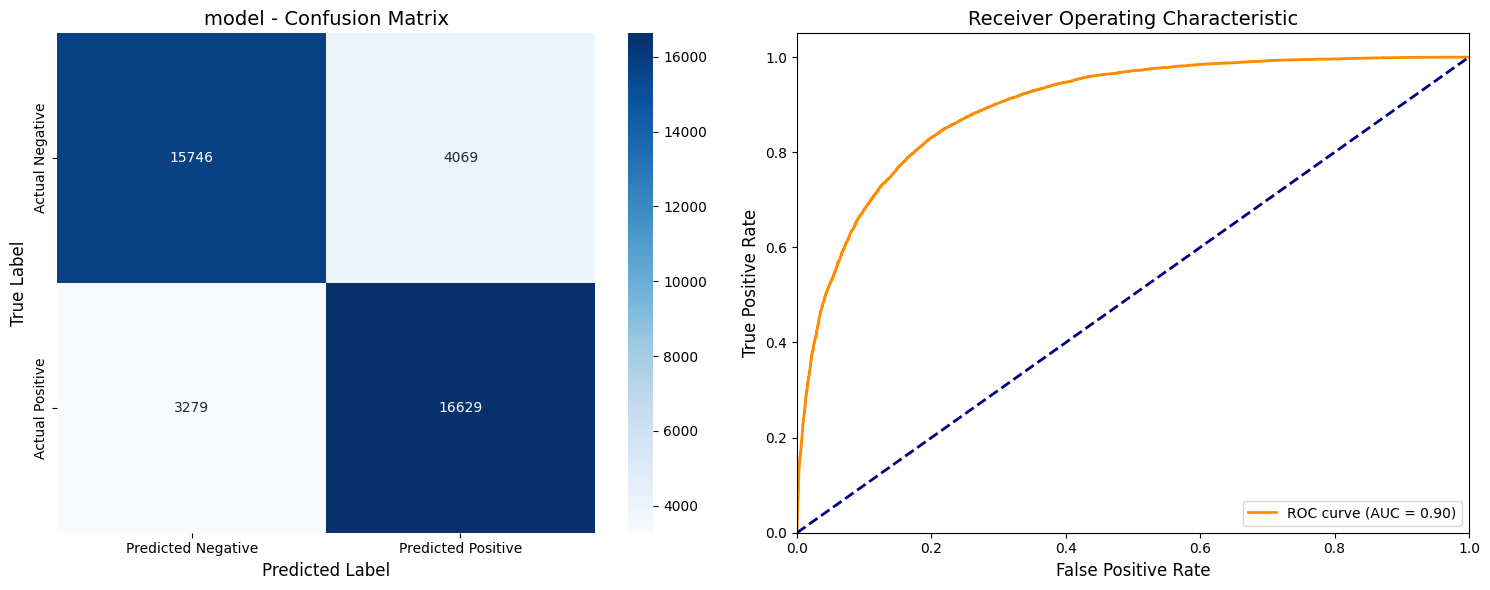

In [22]:
# Гиперпараметры для LSTM модели
LEARNING_RATE = 0.01
BATCH_SIZE = 128
LSTM_UNITS = 8            # количество нейронов в LSTM слое
EMBEDDING_DIM = 20

DROPOUT_RATE = 0.5
RECCURENT_DROPOUT_RATE = 0
DROPOUT_LAYER_RATE = 0.0

REGULARIZATION_STRENGTH = 0.01

# Функция создания LSTM модели
def build_lstm_model():
    model = Sequential([
        # Слой эмбеддингов
        Embedding(input_dim=MAX_NUM_WORDS + 1, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH,
                  embeddings_regularizer=l2_reg(REGULARIZATION_STRENGTH)),
        
        # Двунаправленная LSTM: более сложная архитектура для работы с долгосрочными зависимостями
        Bidirectional(LSTM(LSTM_UNITS, dropout=DROPOUT_RATE, recurrent_dropout=RECCURENT_DROPOUT_RATE, return_sequences=False)),
        
        # Выходной слой для бинарной классификации
        Dense(1, activation="sigmoid")
    ])
    
    optimizer = Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["AUC"])
    return model

# Параметры обучения
fit_params = dict(
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='auc', mode='max', patience=5, restore_best_weights=True)],
    verbose=1
)

# Обучаем LSTM модель с кросс-валидацией
lstm_metrics = cross_validate_model(
    model_builder=build_lstm_model,
    X=X['text'],
    y=y,
    preprocessor=RNN_preprocessor,  # Используем тот же препроцессор
    cv=cv,
    fit_params=fit_params
)

In [23]:
# Результаты обучения LSTM модели
lstm_metrics.name = 'LSTM'
lstm_metrics

ClassificationMetrics(name='LSTM', training_time=2049.5002221999457, estimators=[{'preprocessor': Pipeline(steps=[('token_selector', NgramFeatureSelector()),
                ('seq_vec',
                 SequenceVectorizer(max_sequence_length=600, min_frequency=50,
                                    pad_left=False))]), 'model': <Sequential name=sequential_6, built=True>}, {'preprocessor': Pipeline(steps=[('token_selector', NgramFeatureSelector()),
                ('seq_vec',
                 SequenceVectorizer(max_sequence_length=600, min_frequency=50,
                                    pad_left=False))]), 'model': <Sequential name=sequential_7, built=True>}, {'preprocessor': Pipeline(steps=[('token_selector', NgramFeatureSelector()),
                ('seq_vec',
                 SequenceVectorizer(max_sequence_length=600, min_frequency=50,
                                    pad_left=False))]), 'model': <Sequential name=sequential_8, built=True>}], roc_auc=0.8973359094529765, f1_score

Fold 1


c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │     2,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,200 (7.63 MB)

...

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,200 (7.63 MB)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8684 - loss: 0.4520
Epoch 2/50
 26/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8841 - loss: 0.4253

c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\callbacks\early_stopping.py:100: UserWarning: Early stopping conditioned on metric `auc` which is not available. Available metrics are: AUC,loss
  current = self.get_monitor_value(logs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8890 - loss: 0.4178
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8927 - loss: 0.4111
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8955 - loss: 0.4057
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8970 - loss: 0.4031
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.8982 - loss: 0.4008
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8990 - loss: 0.3991
Epoch 8/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9000 - loss: 0.3974
Epoch 9/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9005 - loss: 0.3961
Epoch 10/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9012 - loss: 0.3950
Epoch 11/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9019 - loss: 0.3938
Epoch 12/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9022 - loss: 0.3931
Epoch 13/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9028 - loss: 0.3919
Epoch 14/50
207/207 ━━━━━━━━━━━━━━━

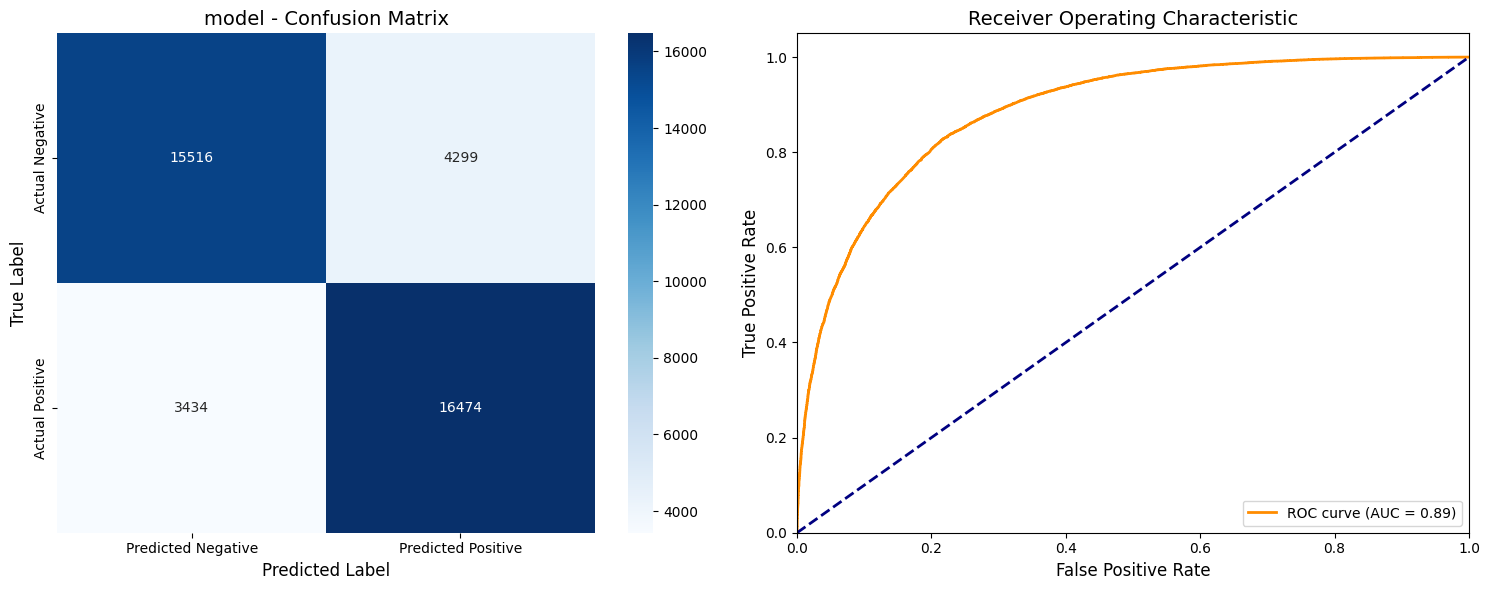

In [24]:
# Загружаем предобученные GloVe эмбеддинги для улучшения качества модели
from typing import Dict, Tuple
import numpy as np

# Параметры GloVe эмбеддингов
GLOVE_DIM: int = 100           # размерность GloVe векторов
GLOVE_MAX_VOCAB: int = 20000   # количество GloVe слов (исключая PAD/OOV)
GLOVE_PATH: str = 'glove.6B.100d.txt'  # путь к файлу GloVe

def _load_glove_fixed_vocab(path: str, embedding_dim: int, max_words: int) -> Tuple[dict, np.ndarray]:
    """Загружает GloVe эмбеддинги и создает словарь с фиксированным размером"""
    vocab: Dict[str, int] = {'<PAD>': 0, '<OOV>': 1}  # специальные токены
    matrix = [np.zeros(embedding_dim, dtype='float32'), np.zeros(embedding_dim, dtype='float32')]

    added = 0
    with open(path, 'r', encoding='utf8') as f:
        for line in f:
            if added >= max_words:
                break
            parts = line.rstrip().split(' ')
            if len(parts) < embedding_dim + 1:
                continue
            token = parts[0]
            if token in vocab:  # пропускаем дубликаты
                continue
            vec = np.asarray(parts[1:], dtype='float32')
            if vec.shape[0] != embedding_dim:
                continue
            # присваиваем следующий ID начиная с 2
            idx = len(vocab)
            vocab[token] = idx
            matrix.append(vec)
            added += 1

    embedding_matrix = np.vstack(matrix)
    return vocab, embedding_matrix

# Загружаем GloVe эмбеддинги
_glove_vocab, _glove_matrix = _load_glove_fixed_vocab(GLOVE_PATH, GLOVE_DIM, GLOVE_MAX_VOCAB)

# Создаем препроцессор с фиксированным словарем GloVe
GLOVE_preprocessor = Pipeline([
    ('token_selector', NgramFeatureSelector(top_k=MAX_NUM_WORDS)),
    ('seq_vec', SequenceVectorizer(
        vocabulary=_glove_vocab,  # используем фиксированный словарь
        max_sequence_length=MAX_SEQUENCE_LENGTH,
        pad_left=False,
    )),
])

# CNN с замороженными GloVe эмбеддингами
def build_cnn_glove_fixed_model():
    model = Sequential([
        # Слой эмбеддингов с предобученными GloVe весами (замороженными)
        Embedding(
            input_dim=_glove_matrix.shape[0],
            output_dim=_glove_matrix.shape[1],
            input_length=MAX_SEQUENCE_LENGTH,
            weights=[_glove_matrix],
            trainable=False,  # замораживаем веса эмбеддингов
        ),
        Conv1D(filters=FILTERS, kernel_size=KERNEL_SIZE, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(1, activation='sigmoid'),
    ])
    optimizer = Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])
    return model

# Обучаем CNN с GloVe эмбеддингами
cnn_glove_fixed_metrics = cross_validate_model(
    model_builder=build_cnn_glove_fixed_model,
    X=X['text'],
    y=y,
    preprocessor=GLOVE_preprocessor,
    cv=cv,
    fit_params=fit_params,
)

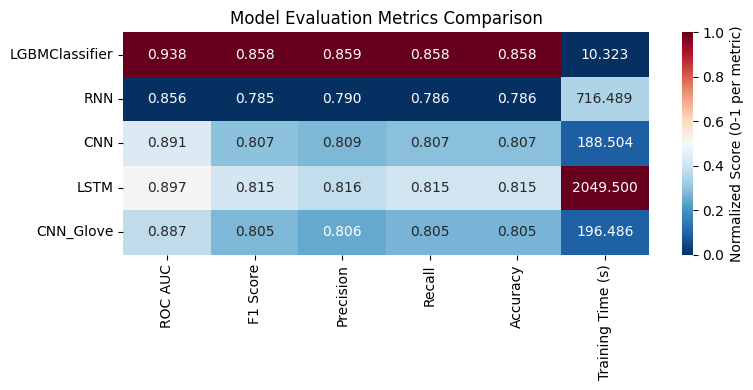

In [27]:
# Сравниваем результаты всех обученных моделей
# Тепловая карта покажет, какая модель показала наилучшие результаты
cnn_glove_fixed_metrics.name = 'CNN_Glove'
plot_metrics_heatmap(
    [
        baseline_metrics,
        rnn_metrics,
        cnn_metrics,
        lstm_metrics,
        cnn_glove_fixed_metrics  
    ]
)